In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy import stats
import os
from stoch_sim_model import *
from optimize_nets import *
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [22]:
sample_virs = np.array(np.meshgrid(d_S*np.logspace(0.0, 2.0, 21), # vary d_I
                                   K_IE*np.logspace(0.0, 2.0, 21), # vary K_IE
                                   b_I*np.logspace(-1, 1, 21) # vary b_I
                                           )).T.reshape(-1,3)

default_reg = np.array([[psi_max/4, psi_max/4, psi_max/2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, psi_max/4, psi_max/4, psi_max/2]])

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/"

In [23]:
# run simulations for extreme scenarios
run(batch = [-1], outdir=d, virus_sample = sample_virs, comment="single-reg-vary-virs", vir_model = "indep_harm", default_reg = default_reg)

Running simulations in batch #-1
Saved sim_batch_-1-1-prim-single-reg-vary-virs.pkl


In [24]:
d_file = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw/sim_batch_-1-1-prim-single-reg-vary-virs.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

n = len(sample_virs)
parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
dyn = data_dict["cell_time_series"]
p_diff = data_dict["prim_diff_bias"]

In [25]:
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
data_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).dropna(thresh=1)

with pd.option_context('display.max_columns', None):
    display(data_df)

,S_0,I_0,b_I,d_S,d_I,d_IE,d_IH,K_IE,K_IH,Aout_0,b_Ain,b_H,d_H,K_EI,K_EH,N_0,max_Na,b_myc,d_myc,myc_thresh,t_act,t_bind,t_Na_div,t_E_div,t_M_div,t_M_diff,t_E_die,t_E_cyt,psi_Nact_I,psi_Nact_H,psi_Nact_IH,psi_NM_I,psi_NM_H,psi_NM_IH,psi_EM_I,psi_EM_H,psi_EM_IH,psi_Ediv_I,psi_Ediv_H,psi_Ediv_IH,p_load,s_load,T_max_pI,T_min_pI,harm_pI,harm_sI,harm_pS,harm_sS,max_pE,max_sE,T_max_pE,T_max_sE,inf_pM,inf_sM,init_M,int_pE,int_sE,int_pH,int_sH,min_pS,min_sS
0,10000000.0,100.0,1.000000e-08,0.01,0.01,12.0,0.0,10000.000000,5000.0,1000.0,1.0,1.0,2.0,10000.000000,5000.0,100.0,8.0,2123.238243,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,25.0,2.0,0.666667,0.5,0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,1.0,3.165818e+03,3.165818e+03,20.000,0.0,4.164694e+02,4.164694e+02,430.025657,430.025657,125.0,125.0,4.324,4.324,19.0,19.0,5.0,752.680,752.680,1.522069e+01,1.522069e+01,9.999322e+06,9.999322e+06
1,10000000.0,100.0,1.000000e-08,0.01,0.01,12.0,0.0,12589.254118,5000.0,1000.0,1.0,1.0,2.0,12589.254118,5000.0,100.0,8.0,2123.238243,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,25.0,2.0,0.666667,0.5,0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,1.0,4.245375e+03,4.245375e+03,20.000,0.0,5.243700e+02,5.243700e+02,282.142769,282.142769,61.0,61.0,15.352,15.352,17.0,17.0,2.0,493.808,493.808,2.030733e+01,2.030733e+01,9.999350e+06,9.999350e+06
2,10000000.0,100.0,1.000000e-08,0.01,0.01,12.0,0.0,15848.931925,5000.0,1000.0,1.0,1.0,2.0,15848.931925,5000.0,100.0,8.0,2123.238243,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,25.0,2.0,0.666667,0.5,0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,1.0,4.267337e+03,4.267337e+03,20.000,0.0,5.265614e+02,5.265614e+02,338.081089,338.081089,103.0,103.0,17.048,17.048,11.0,11.0,3.0,591.704,591.704,2.039907e+01,2.039907e+01,9.999298e+06,9.999298e+06
3,10000000.0,100.0,1.000000e-08,0.01,0.01,12.0,0.0,19952.623150,5000.0,1000.0,1.0,1.0,2.0,19952.623150,5000.0,100.0,8.0,2123.238243,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,25.0,2.0,0.666667,0.5,0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,1.0,4.709848e+03,4.709848e+03,20.000,0.0,5.707771e+02,5.707771e+02,231.843816,231.843816,76.0,76.0,6.272,6.272,11.0,11.0,3.0,405.736,405.736,2.241170e+01,2.241170e+01,9.999356e+06,9.999356e+06
4,10000000.0,100.0,1.000000e-08,0.01,0.01,12.0,0.0,25118.864315,5000.0,1000.0,1.0,1.0,2.0,25118.864315,5000.0,100.0,8.0,2123.238243,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,25.0,2.0,0.666667,0.5,0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,1.0,4.846426e+03,4.846426e+03,20.000,0.0,5.844305e+02,5.844305e+02,272.054015,272.054015,76.0,76.0,8.128,8.128,11.0,11.0,2.0,476.136,476.136,2.307357e+01,2.307357e+01,9.999303e+06,9.999303e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9256,10000000.0,100.0,1.000000e-06,0.01,1.00,12.0,0.0,398107.170553,5000.0,1000.0,1.0,1.0,2.0,398107.170553,5000.0,100.0,8.0,2123.238243,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,25.0,2.0,0.666667,0.5,0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,1.0,9.853019e+06,9.853019e+06,1.564,0.0,1.023665e+07,1.023665e+07,11475.587404,11475.587404,451758.0,451758.0,6.368,6.368,21388.0,21388.0,3882.0,789318.404,789318.404,4.926509e+06,4.926509e+06,3.398939e+04,3.398939e+04
9257,10000000.0,100.0,1.000000e-06,0.01,1.00,12.0,0.0,501187.233627,5000.0,1000.0,1.0,1.0,2.0,501187.233627,5000.0,100.0,8.0,2123.238243,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,25.0,2.0,0.666667,0.5,0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,1.0,9.917091e+06,9.917091e+06,1.564,0.0,1.024385e+07,1.024385e+07,11801.214741,11801.214741,503065.0,503065.0,6.444,6.444,20593.0,20593.0,3251.0,789373.016,789373.016,4.958545e+06,4.958545e+06,3.398583e+04,3.398583e+04
9258,10000000.0,100.0,1.000000e-06,0.01,1.00,12.0,0.0,630957.344480,5000.0,1000.0,1.0,1.0,2.0,630957.344480,5000.0,100.0,8.0,2123.238243,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,25.0,2.0

Text(0.5, 0, 'Max-scaled parameter')

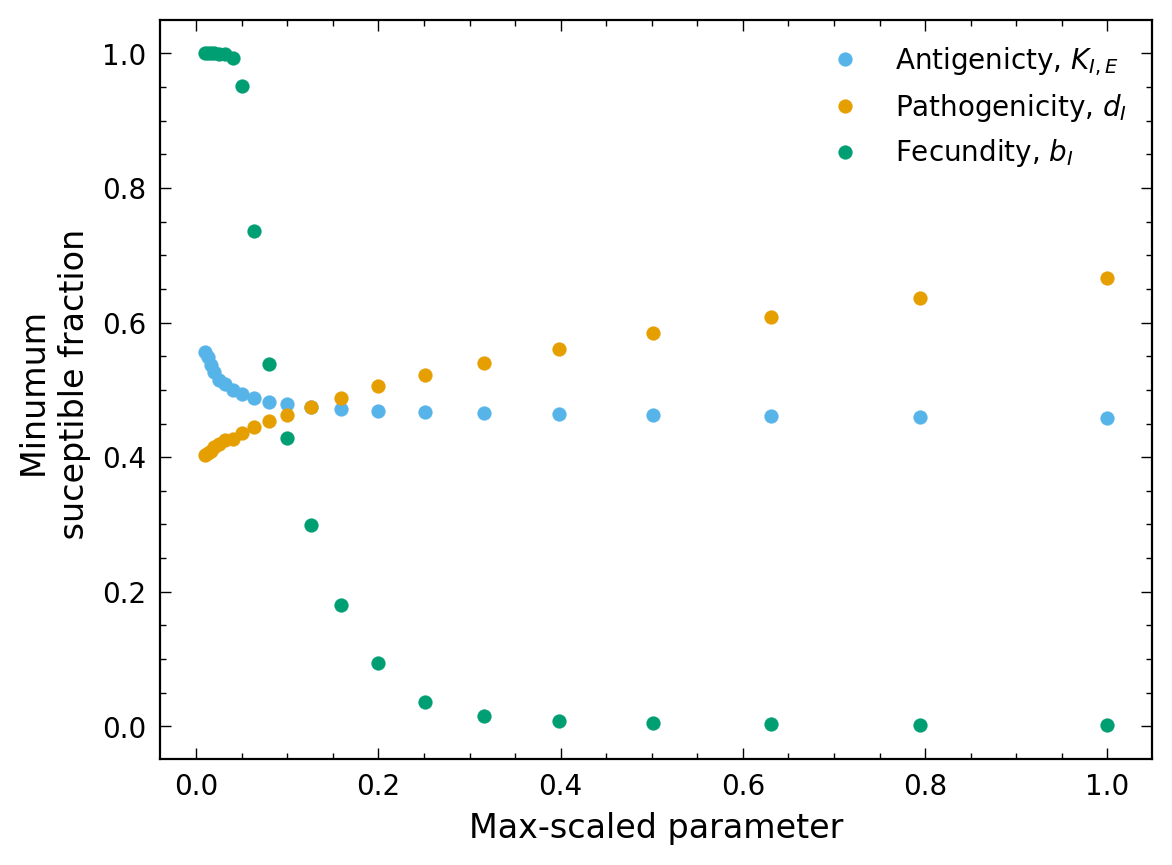

In [26]:
plt.plot(data_df.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(data_df['K_IE']), data_df.groupby(['K_IE'], as_index=False).mean()['min_pS']/S_0, 'o', label = 'Antigenicty, $K_{I,E}$')
plt.plot(data_df.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(data_df['d_I']), data_df.groupby(['d_I'], as_index=False).mean()['min_pS']/S_0, 'o', label = 'Pathogenicity, $d_{I}$')
plt.plot(data_df.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(data_df['b_I']), data_df.groupby(['b_I'], as_index=False).mean()['min_pS']/S_0, 'o', label = 'Fecundity, $b_{I}$')
plt.legend()
plt.ylabel('Minumum \n suceptible fraction')
plt.xlabel('Max-scaled parameter')

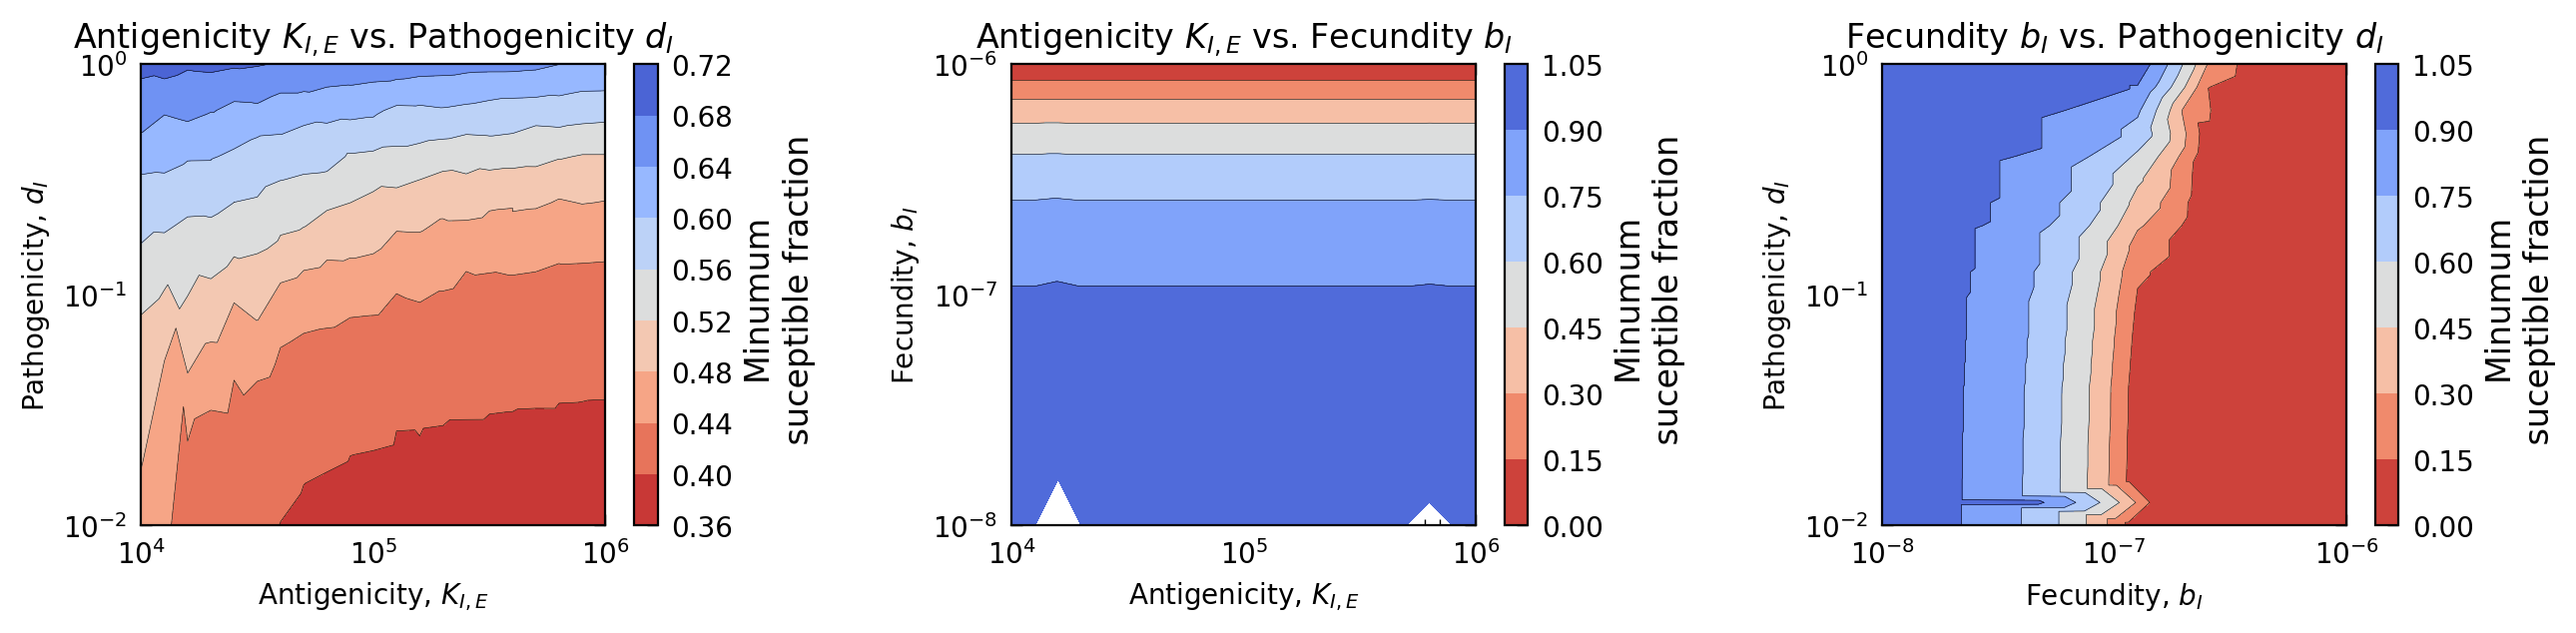

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

axs[0].tricontour(data_df.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                  data_df.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                  data_df.groupby(['K_IE','d_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.2, colors='k')
im0 = axs[0].tricontourf(data_df.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                        data_df.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                        data_df.groupby(['K_IE','d_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r")

cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[1].tricontour(data_df.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                  data_df.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                  data_df.groupby(['K_IE','b_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.2, colors='k')
im1 = axs[1].tricontourf(data_df.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                        data_df.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                        data_df.groupby(['K_IE','b_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r")

cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[2].tricontour(data_df.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                  data_df.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                  data_df.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.2, colors='k')
im2 = axs[2].tricontourf(data_df.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                        data_df.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                        data_df.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r")

cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Pathogenicity $d_I$", fontsize = 12)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 12)
axs[2].set_title(r"Fecundity $b_I$ vs. Pathogenicity $d_I$", fontsize = 12)

axs[0].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 10)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[2].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
axs[2].set_xlabel("Fecundity, $b_I$", fontsize = 10)

for j, ax in enumerate(axs.flat):
    ax.semilogy()
    ax.semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_contour', dpi=300, bbox_inches='tight')

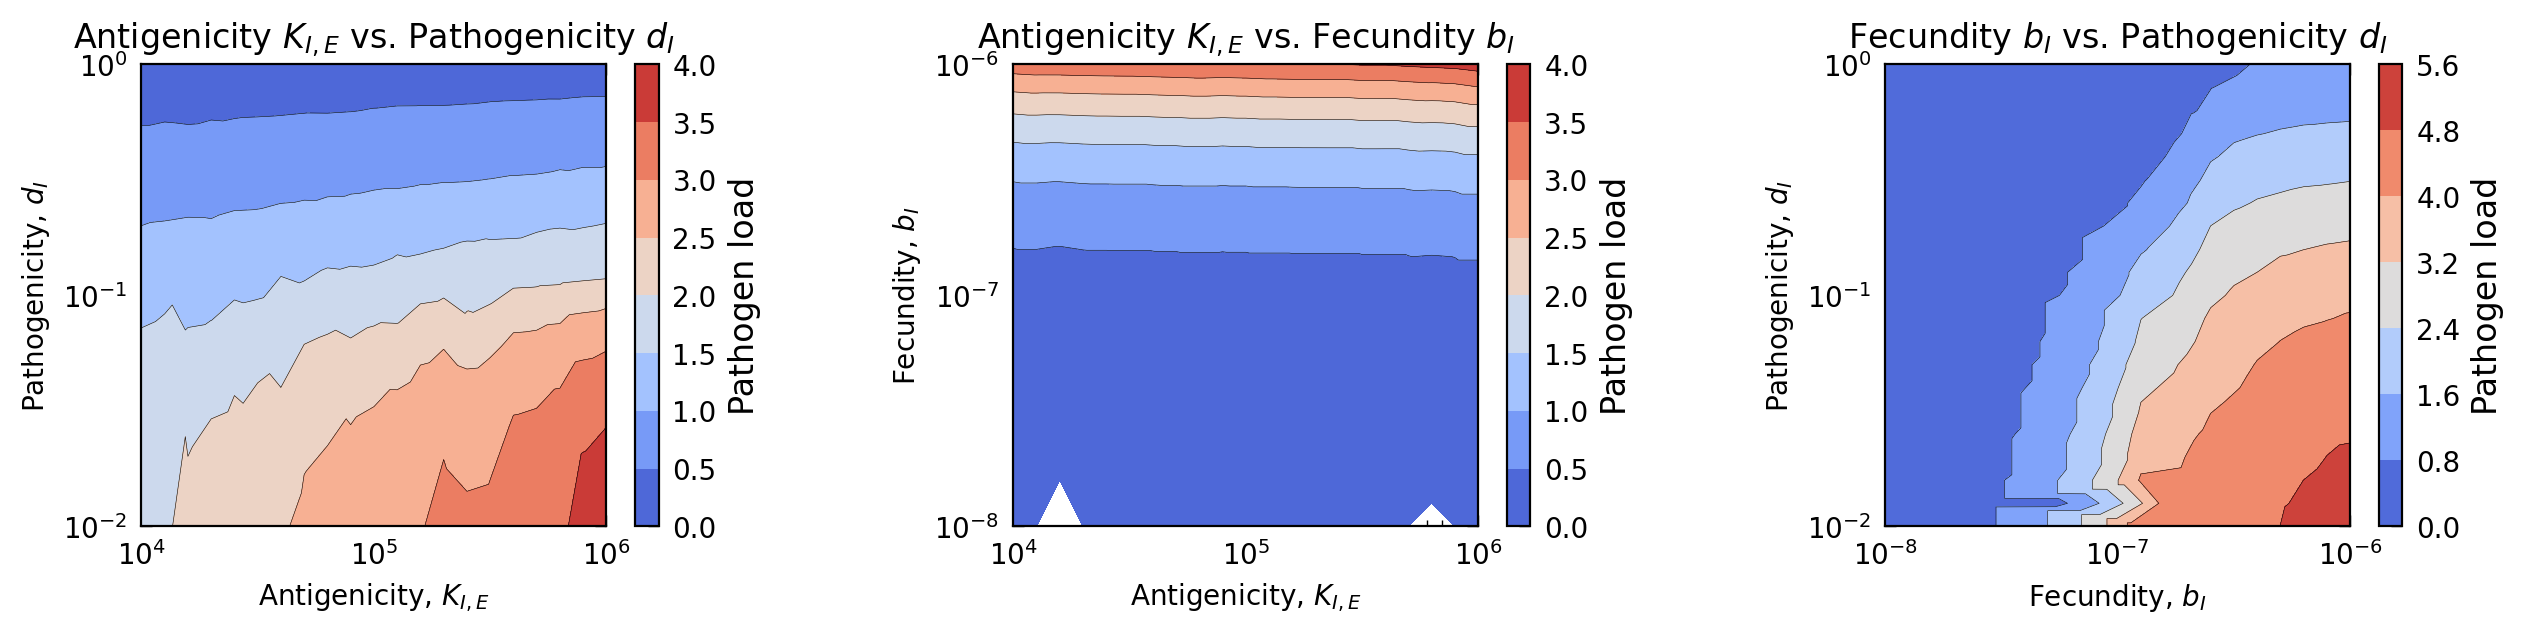

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

axs[0].tricontour(data_df.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                  data_df.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                  data_df.groupby(['K_IE','d_I'], as_index=False).mean()['p_load']/S_0, linewidths=0.2, colors='k')
im0 = axs[0].tricontourf(data_df.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                        data_df.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                        data_df.groupby(['K_IE','d_I'], as_index=False).mean()['p_load']/S_0, cmap="coolwarm")

cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Pathogen load", fontsize = 12)

axs[1].tricontour(data_df.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                  data_df.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                  data_df.groupby(['K_IE','b_I'], as_index=False).mean()['p_load']/S_0, linewidths=0.2, colors='k')
im1 = axs[1].tricontourf(data_df.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                        data_df.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                        data_df.groupby(['K_IE','b_I'], as_index=False).mean()['p_load']/S_0, cmap="coolwarm")

cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Pathogen load", fontsize = 12)

axs[2].tricontour(data_df.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                  data_df.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                  data_df.groupby(['b_I','d_I'], as_index=False).mean()['p_load']/S_0, linewidths=0.2, colors='k')
im2 = axs[2].tricontourf(data_df.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                        data_df.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                        data_df.groupby(['b_I','d_I'], as_index=False).mean()['p_load']/S_0, cmap="coolwarm")

cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Pathogen load", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Pathogenicity $d_I$", fontsize = 12)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 12)
axs[2].set_title(r"Fecundity $b_I$ vs. Pathogenicity $d_I$", fontsize = 12)

axs[0].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 10)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[2].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
axs[2].set_xlabel("Fecundity, $b_I$", fontsize = 10)

for j, ax in enumerate(axs.flat):
    ax.semilogy()
    ax.semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_pload_contour', dpi=300, bbox_inches='tight')

In [29]:
# fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

# im0 = axs[0].scatter(data_df.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], data_df.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', 
#                     c = data_df.groupby(['K_IE','d_I'], as_index=False).mean()['min_pS']/S_0, cmap='coolwarm_r')
# cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
# cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

# im1 = axs[1].scatter(data_df.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], data_df.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', 
#                c = data_df.groupby(['K_IE','b_I'], as_index=False).mean()['min_pS']/S_0, cmap='coolwarm_r')
# cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
# cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

# im2 = axs[2].scatter(data_df.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], data_df.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], marker = 's', 
#                c = data_df.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, cmap='coolwarm_r')
# cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
# cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

# axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Pathogenicity $d_I$", fontsize = 12)
# axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 12)
# axs[2].set_title(r"Fecundity $b_I$ vs. Pathogenicity $d_I$", fontsize = 12)

# axs[0].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
# axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
# axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 10)
# axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
# axs[2].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
# axs[2].set_xlabel("Fecundity, $b_I$", fontsize = 10)

# for j, ax in enumerate(axs.flat):
#     ax.semilogy()
#     ax.semilogx()

# fig.subplots_adjust(wspace=.5, hspace=.5)
    
# plt.savefig('_figs/vir_parameter_w_Smin_heatmaps', dpi=300, bbox_inches='tight')

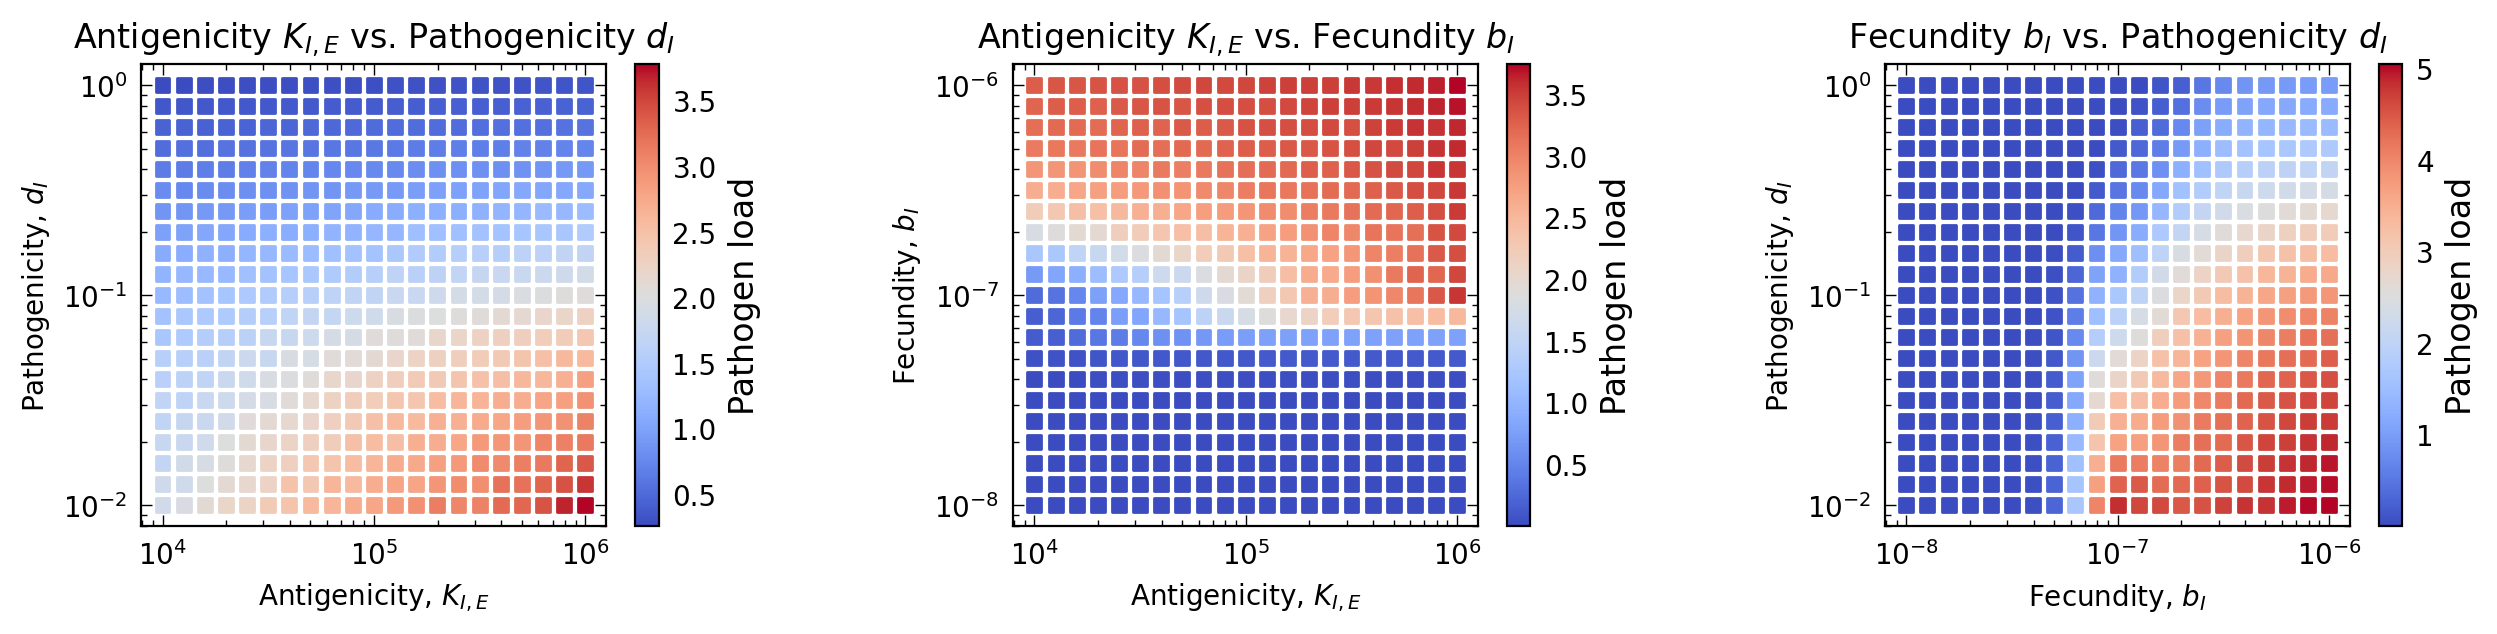

In [30]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(data_df.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], data_df.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', 
                    c = data_df.groupby(['K_IE','d_I'], as_index=False).mean()['p_load']/S_0, cmap='coolwarm')
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Pathogen load", fontsize = 12)

im1 = axs[1].scatter(data_df.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], data_df.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', 
               c = data_df.groupby(['K_IE','b_I'], as_index=False).mean()['p_load']/S_0, cmap='coolwarm')
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Pathogen load", fontsize = 12)

im2 = axs[2].scatter(data_df.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], data_df.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], marker = 's', 
               c = data_df.groupby(['b_I','d_I'], as_index=False).mean()['p_load']/S_0, cmap='coolwarm')
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Pathogen load", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Pathogenicity $d_I$", fontsize = 12)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 12)
axs[2].set_title(r"Fecundity $b_I$ vs. Pathogenicity $d_I$", fontsize = 12)

axs[0].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 10)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[2].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
axs[2].set_xlabel("Fecundity, $b_I$", fontsize = 10)

for j, ax in enumerate(axs.flat):
    ax.semilogy()
    ax.semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_pload_heatmaps', dpi=300, bbox_inches='tight')

In [9]:
d_file = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw/sim_batch_-1-1-prim-single-reg-vary-virs.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

n = len(sample_virs)
dyn = data_dict["cell_time_series"]
p_diff = data_dict["prim_diff_bias"]
keep = [i*int(sim_steps/pnts) for i in np.arange(0,pnts)]
rows = 2

fig, axs = plt.subplots(int(n/2), int(n/2), figsize=(2*n + 2, 2*n), sharex=True, sharey=True)

for l, (d_I, K_IE) in enumerate(extreme_virs):
    dyn_data = dyn[l][keep]
    p_diff_data = p_diff[l][keep]
    time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]
    
    pS, sS, pI, sI, Ain, pN, pE, sE, pcM, scM, peM, seM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_data[:,0], dyn_data[:,-10], dyn_data[:,1], dyn_data[:,-9], dyn_data[:,-8], dyn_data[:,3], dyn_data[:, 4], dyn_data[:,-6], dyn_data[:,5], dyn_data[:, -5], dyn_data[:,6], dyn_data[:,-4], dyn_data[:,7], dyn_data[:,-3], dyn_data[:,8], dyn_data[:,-2], dyn_data[:,9],dyn_data[:,-1]

    x,y = int(np.floor(rows*l/n)), l % int(np.ceil((n/rows)))

    [axs[x,y].axvline(x=time[k], linestyle='-', linewidth=0.2, color='limegreen', alpha=pH[k]) for k in np.arange(0, len(pH)-1)]
    axs[x,y].plot(time, pN, 'k--')
    im = axs[x,y].scatter(time, pN, marker = 's', c = pI/S_0, cmap='coolwarm', label = r'Act. naive, $N^*$')
    
    axs[x,y].plot(time, pE, 'k--')
    axs[x,y].scatter(time, pE, marker = 'o', c = pI/S_0, cmap='coolwarm', label = r'Effector, $E$')

    axs[x,y].plot(time, pcM + peM, 'k--')
    axs[x,y].scatter(time, pcM + peM, marker = '^', c = pI/S_0, cmap='coolwarm', label = r'Memory, $cM + eM$')

    axs[x,y].set_title(r"$d_I =$ "+str(np.round(d_I,3))+r", $K_{IE} =$ "+str(format(K_IE,'.0e')), fontsize = 8)

    # # inset plot: these are in unitless percentages of the figure size. (0,0 is bottom left)
    axins = inset_axes(axs[x,y], width="25%", height="25%", loc=2, borderpad = 2.6)
    axins.plot(time, p_diff_data[:,0], 'k--')
    axins.scatter(time, p_diff_data[:,0], marker = 'o', c = pI/S_0, cmap='coolwarm') #, label = r'Bias$_t(N^* \longrightarrow E)$')
    axins.set(xlabel=r'$t$')
    axins.set_title(r'$N^* \longrightarrow E$', fontsize = 8)
    axins.axis([0.0, time[-1], 0.0, 1.0])
       
    if y == 0:
        axs[x,0].set(ylabel = "T-cell response")
        # axs[0,0].legend(loc='upper right')

    if x == int(n/rows)-1:
        axs[x,y].set(xlabel= r"time, $t$ (days)")

axs[0,1].axvline(x=time[np.argmax(pH)], linestyle='-', linewidth=0.3, color='limegreen', alpha=pH[np.argmax(pH)], label =r"Inflammation, $H$")
axs[0,1].legend(loc='center right', bbox_to_anchor=(2.2, 0.8), fontsize = 12)

cb = fig.colorbar(im, ax=axs, orientation='vertical')
cb.set_label("Infected to susceptible ratio", fontsize = 16)
    
for i, ax in enumerate(axs.flat):
    ax.semilogy()

# for ax in axs.flat:
#     ax.label_outer()
        
plt.savefig('_figs/dI_KIE_response_dynamics', dpi=300, bbox_inches='tight')

NameError: name 'pnts' is not defined

In [ ]:
# Plot trends for different networks based on signal correlation
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/cell_time_series/mean/'
d_std = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/cell_time_series/std/'

n = len(virs)
fig, axs = plt.subplots(3, n, figsize=(8, 6), sharex=True)


for file_count, f in enumerate(tqdm(os.listdir(d_mean))):
    if '-100-' not in f or infection_type not in f:
        continue
    dyn_net = np.load(os.path.join(d_mean, f))
    #dyn_std = np.load(os.path.join(d_std, f))
    keep = [i*int(sim_steps/pnts) for i in np.arange(0,pnts)]
    
    for l, (d_I, K_IE) in enumerate(virs):
        dyn_mean = dyn_net[l+1][keep]
    
        pS, sS, pI, sI, Ain, N, pE, sE, pcM, scM, peM, seM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_mean[:,0], dyn_mean[:,-10], dyn_mean[:,1], dyn_mean[:,-9], dyn_mean[:,-8], dyn_mean[:,-7], dyn_mean[:, 4], dyn_mean[:,-6], dyn_mean[:,5], dyn_mean[:, -5], dyn_mean[:,6], dyn_mean[:,-4], dyn_mean[:,7], dyn_mean[:,-3], dyn_mean[:,8], dyn_mean[:,-2], dyn_mean[:,9], dyn_mean[:,-1]
    
        time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]
        
    
        # axs[0,l].plot(time, pS, color='grey', 
        #             label = r'Susceptible, $S_p$') #, norm=mpl.colors.LogNorm())
        axs[0,l].plot(time, pI, color='grey',
                    label = r'Infected, $I_p$', alpha = 0.01)
        axs[1,l].plot(time, pE, color='grey',
                    label = r'Effector, $E_p$', alpha = 0.01)
        axs[2,l].plot(time, pcM + peM, color='grey',
                    label = r'Memory, $cM_p+eM_p$', alpha = 0.01)
        # axs[4,l].plot(time, pH, color='grey',
        #             label = r'Inflammation, $H_p$')
        
        axs[0,l].set_title(r"$d_I =$ "+str(np.round(d_I,3))+r", $K_{I,E} =$ "+str(np.round(K_IE,0)), fontsize = 8)
        
        # if file_count == 0:
        #     axs[0,0].legend(fontsize = 8)
        #     axs[1,0].legend(fontsize = 8)
        #     axs[2,0].legend(fontsize = 8)
        #     axs[3,0].legend(fontsize = 8)
        #     axs[4,0].legend(fontsize = 8)

y_labels = [r'Infected, $I_p$',r'Effector, $E_p$',r'Memory, $cM_p+eM_p$']
for i, ax in enumerate(axs.flat):
    ax.set(xlabel= r"time, $t$ (days)")
    ax.set_yscale('log')
    if i % 4 == 0:
        ax.set(ylabel= y_labels[int(i/4)])

for ax in axs.flat:
    ax.label_outer()
        
#plt.savefig('_figs/dI_KIE_response_dynamics', dpi=300, bbox_inches='tight')

In [ ]:
# Plot trends for different networks based on signal correlation
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/diff_bias/mean/'
d_std = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/diff_bias/std/'

n = len(vir_prop)
fig, axs = plt.subplots(3, n, figsize=(10, 6), sharex=True, sharey = True)

for file_count, f in enumerate(tqdm(os.listdir(d_mean))):
    if '-100-' not in f or infection_type not in f:
        continue
    diff_bias_net = np.load(os.path.join(d_mean, f))
    keep = [i*int(sim_steps/pnts) for i in np.arange(0,pnts)]
    
    for l, (d_I, K_IE) in enumerate(virs):
        diff_bias = diff_bias_net[l][keep]
        time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]
    
        axs[0,l].plot(time, diff_bias[:,0], color='grey', 
                    label = r'Bias$_t(N^* \longrightarrow E)$', alpha = 0.01)
        axs[1,l].plot(time, diff_bias[:,1], color='grey',
                    label = r'Bias$_t(E_{in} \longrightarrow eM)$', alpha = 0.01)
        axs[2,l].plot(time, diff_bias[:,2], color='grey',
                    label = r'Bias$_t(E_{out} \longrightarrow eM)$', alpha = 0.01)
        
        axs[0,l].set_title(r"$d_I =$ "+str(np.round(d_I,3))+r", $K_{I,E} =$ "+str(np.round(K_IE,0)), fontsize = 8)
        
        if file_count == 0:
            axs[0,0].legend(fontsize = 8)
            axs[1,0].legend(fontsize = 8)
            axs[2,0].legend(fontsize = 8)
    
for i, ax in enumerate(axs.flat):
    ax.set(xlabel= r"time, $t$ (days)")

for ax in axs.flat:
    ax.label_outer()
        
#plt.savefig('_figs/dI_KIE_response_dynamics', dpi=300, bbox_inches='tight')

In [ ]:
# Plot trends for different networks based on signal correlation
n = len(vir_prop[1:])
n_d_I, n_K_IE = len(np.unique(virs[:,1])), len(np.unique(virs[:,0]))
fig, axs = plt.subplots(n_K_IE, n_d_I, figsize=(8, 6), sharex=True, sharey=True)


for file_count, f in enumerate(tqdm(os.listdir(d_mean)[0:5])):
    if '-100-' not in f or infection_type not in f:
        continue
    dyn_net = np.load(os.path.join(d_mean, f))
    #dyn_std = np.load(os.path.join(d_std, f))
    
    for l, (d_I, K_IE) in enumerate(virs):
        dyn_mean = dyn_net[l+1]
        x,y = l % n_d_I, int(np.floor(l/n_K_IE))
    
        pS, sS, pI, sI, Ain, N, pE, sE, pcM, scM, peM, seM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_mean[:,0], dyn_mean[:,-10], dyn_mean[:,1], dyn_mean[:,-9], dyn_mean[:,-8], dyn_mean[:,-7], dyn_mean[:, 4], dyn_mean[:,-6], dyn_mean[:,5], dyn_mean[:, -5], dyn_mean[:,6], dyn_mean[:,-4], dyn_mean[:,7], dyn_mean[:,-3], dyn_mean[:,8], dyn_mean[:,-2], dyn_mean[:,9], dyn_mean[:,-1]
        
        keep = [i*int(len(pE)/pnts) for i in np.arange(0,pnts)]
        psus = pS[keep]
        naive = N[keep]
        peff = pE[keep]
        pmem = (pcM+peM)[keep]
        p_load = pI[keep]/np.max(pI)
        time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]
    
        im = axs[x,y].scatter(time, naive, marker ='s', c =p_load, cmap='coolwarm', 
                    label = r'Act. naive, $N^*$') #, norm=mpl.colors.LogNorm())
        axs[x,y].plot(time, naive, 'k--', alpha = 0.1)
        axs[x,y].plot(time, peff, 'k--', alpha = 0.1)
        axs[x,y].plot(time, pmem, 'k--', alpha = 0.1)
        axs[x,y].set_title(r"$d_I =$ "+str(np.round(d_I,3))+r", $K_{IE} =$ "+str(np.round(K_IE,0)), fontsize = 8)
        #axs[x,y].set_title("d_I = {}".format(np.round(d_I,3))+", K_IE = {}".format(K_IE), fontsize = 8)
        
        if x == 0 and y == 0 and file_count == 0:
            axs[x,y].legend(fontsize = 8)
    
for i, ax in enumerate(axs.flat):
    ax.set(xlabel= r"time, $t$ (days)",
           ylabel= 'cellular response')
    ax.set_yscale('log')

for ax in axs.flat:
    ax.label_outer()
    
cb = fig.colorbar(im, ax=axs, orientation='vertical')
cb.set_label(r"Infection progression, $\frac{I}{max(I_{0 \to t})}$")
        
#plt.savefig('_figs/dI_KIE_response_dynamics', dpi=300, bbox_inches='tight')